# **Name**: **Bibisha sapkota**

# **ID:2438425**
# Brain Tumor Classification using Convolutional Neural Networks
### 6CS012 Final Portfolio Project 2026 — Part II: Vision Tasks
**Dataset:** Brain Tumor MRI Classification — 4 classes: Glioma, Meningioma, Normal, Pituitary
### Project Overview
This notebook implements an end-to-end image classification pipeline for detecting brain tumors from MRI scans. Medical image classification is a high-stakes application where model interpretability and accuracy are both important — a misclassification can have real clinical consequences.


**Data Understanding, Analysis, Visualization and Cleaning:**

Before building models, analyze and understand the dataset by answering the following questions:

**• What does the dataset represent? Provide a brief description.**

    The dataset represents MRI brain scan images used for brain tumor classification.
    Its main objective is to classify brain MRI images into four different categories:

    Glioma Tumor
    Meningioma Tumor
    Pituitary Tumor
    Normal (No Tumor)


• How many total images are in the dataset?

    Initially, the dataset contained slightly more images, but during preprocessing and integrity checking:

    28 corrupted image files were detected and removed to ensure data quality and prevent training errors.

    After cleaning:

    Dataset Split
    Training + Validation Images =	2,447
    Test Images =	621
    Total Images = 3,068

• What is the distribution of images across different classes?

    The dataset contains four classes:

    glioma_tumor
    meningioma_tumor
    normal
    pituitary_tumor

    The cleaned dataset was loaded successfully with all four classes available in training, validation, and testing stages.

• How is the dataset split into training and validation sets? Justify your choice.

    The dataset was divided into:

    Training Set = 1,960
    Validation Set = 487
    Test Set = 621

    This corresponds approximately to:

    80% Training
    20% Validation (from training data)
    Separate Test Set for final evaluation

• What preprocessing techniques (e.g., resizing, normalization) were applied?
    Several preprocessing techniques were applied before training the CNN models.
    
    Image Re-sizing, Normalization, Corrupted Image Removoal

• What data generators, if any, were used for preprocessing and augmentation?

    ImageDataGenerator from TensorFlow/Keras was used.
    Training Generator = training data loading, augmentation and shuffling.
    Validation Generator = validation during training, without augmentation,to evaluate true model performance.
    Test Generator = final evaluation,prediction and performance metrics.

• If data augmentation was applied, provide visualizations of sample augmented images.

    Data augmentation was applied to improve model generalization and reduce overfitting.
    Typical augmentation techniques used include: Rotation, Zoom, Horizontal flipping, Width/height shifting, Shearing
    
    Figure below:

---
##  Install & Import Dependencies

In [1]:

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from collections import Counter


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, ResNet50V2


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow Version : {tf.__version__}")
print(f"Keras Version      : {keras.__version__}")
print(f"GPU Available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow Version : 2.20.0
Keras Version      : 3.13.2
GPU Available      : []


---
##  Section 1: Dataset Paths — Update This!

In [11]:
TRAIN_DIR = r'/content/drive/MyDrive/AI_FINAL YEAR/AI ML/Assesment final/Assesment_part2/Brain Tumor Classifcation-20260428T081530Z-3-001/Brain Tumor Classifcation/train'
TEST_DIR  = r'/content/drive/MyDrive/AI_FINAL YEAR/AI ML/Assesment final/Assesment_part2/Brain Tumor Classifcation-20260428T081530Z-3-001/Brain Tumor Classifcation/test'
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
EPOCHS_BASE = 30
EPOCHS_DEEP = 40
NUM_CLASSES = 4
CLASS_NAMES = ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']
SEED        = 42

print("Paths configured.")

Paths configured.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



##  Section 2: Data Understanding, Analysis & Visualization

Before building any model it is important to understand the data. Brain tumor MRI images vary significantly in appearance across tumor types — gliomas tend to appear as irregular, diffuse masses, while meningiomas are usually well-defined and located near the brain periphery. Normal scans show no visible mass, and pituitary tumors appear at the base of the brain.

We check:
- **Class distribution** — are the classes balanced? Imbalance affects which metrics matter.
- **Sample images** — do the images look as expected? Are there obvious artifacts?
- **Image dimensions** — do we need to resize, and to what target size?

In [13]:
# ── Count images per class in train and test ──────────────────────────────────
def count_images(base_dir):
    counts = {}
    total  = 0
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            counts[cls] = n
            total += n
    return counts, total

train_counts, train_total = count_images(TRAIN_DIR)
test_counts,  test_total  = count_images(TEST_DIR)

print("=" * 50)
print(f"{'Class':<25} {'Train':>8} {'Test':>8}")
print("=" * 50)
for cls in CLASS_NAMES:
    print(f"{cls:<25} {train_counts.get(cls, 0):>8} {test_counts.get(cls, 0):>8}")
print("-" * 50)
print(f"{'TOTAL':<25} {train_total:>8} {test_total:>8}")
print("=" * 50)

Class                        Train     Test
glioma_tumor                   713      181
meningioma_tumor               723      183
normal                         343       88
pituitary_tumor                668      169
--------------------------------------------------
TOTAL                         2447      621


In [14]:
import os
base_dataset_path = os.path.dirname(os.path.dirname(TRAIN_DIR))

print(f"Checking contents of: {base_dataset_path}")
if os.path.exists(base_dataset_path):
    print("Contents:")
    for item in sorted(os.listdir(base_dataset_path)):
        print(f"- {item}")
else:
    print(f"The base directory '{base_dataset_path}' does not exist.")

Checking contents of: /content/drive/MyDrive/AI_FINAL YEAR/AI ML/Assesment final/Assesment_part2/Brain Tumor Classifcation-20260428T081530Z-3-001
Contents:
- Brain Tumor Classifcation


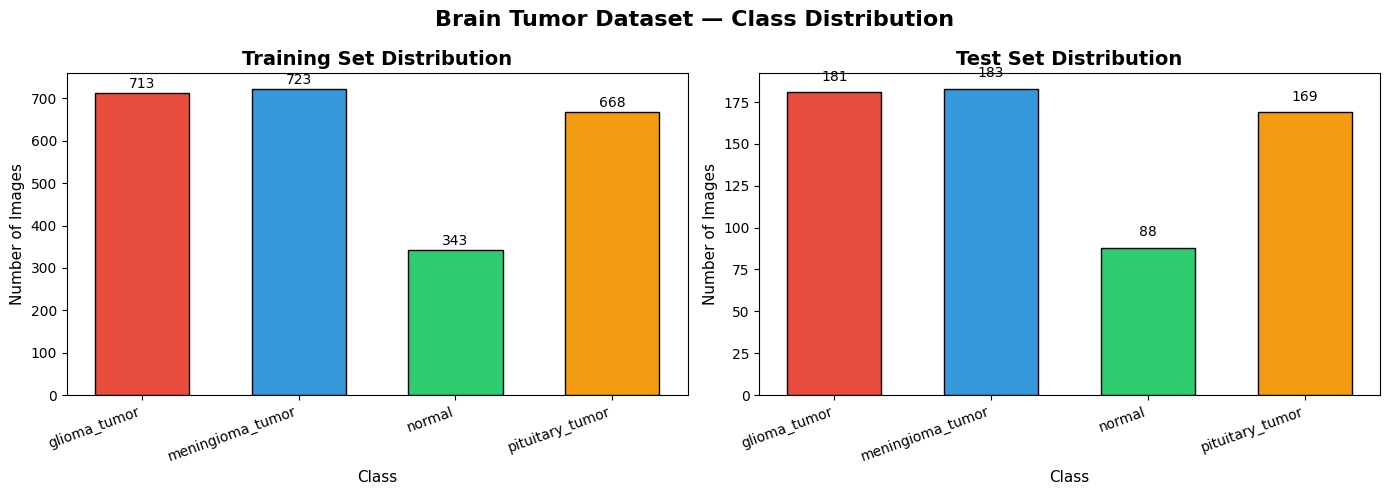

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Training Set Distribution', 'Test Set Distribution']
):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'],
                  edgecolor='black', width=0.6)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.set_xticklabels(counts.keys(), rotation=20, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.suptitle('Brain Tumor Dataset — Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The chart shows a clear class imbalance — Glioma, Meningioma, and Pituitary Tumor each have around 700 training images, while the Normal class has only 343, roughly half of the others. This same gap appears in the test set too. This means the model sees far fewer healthy brain scans during training, which can cause it to misclassify normal brains as tumorous.

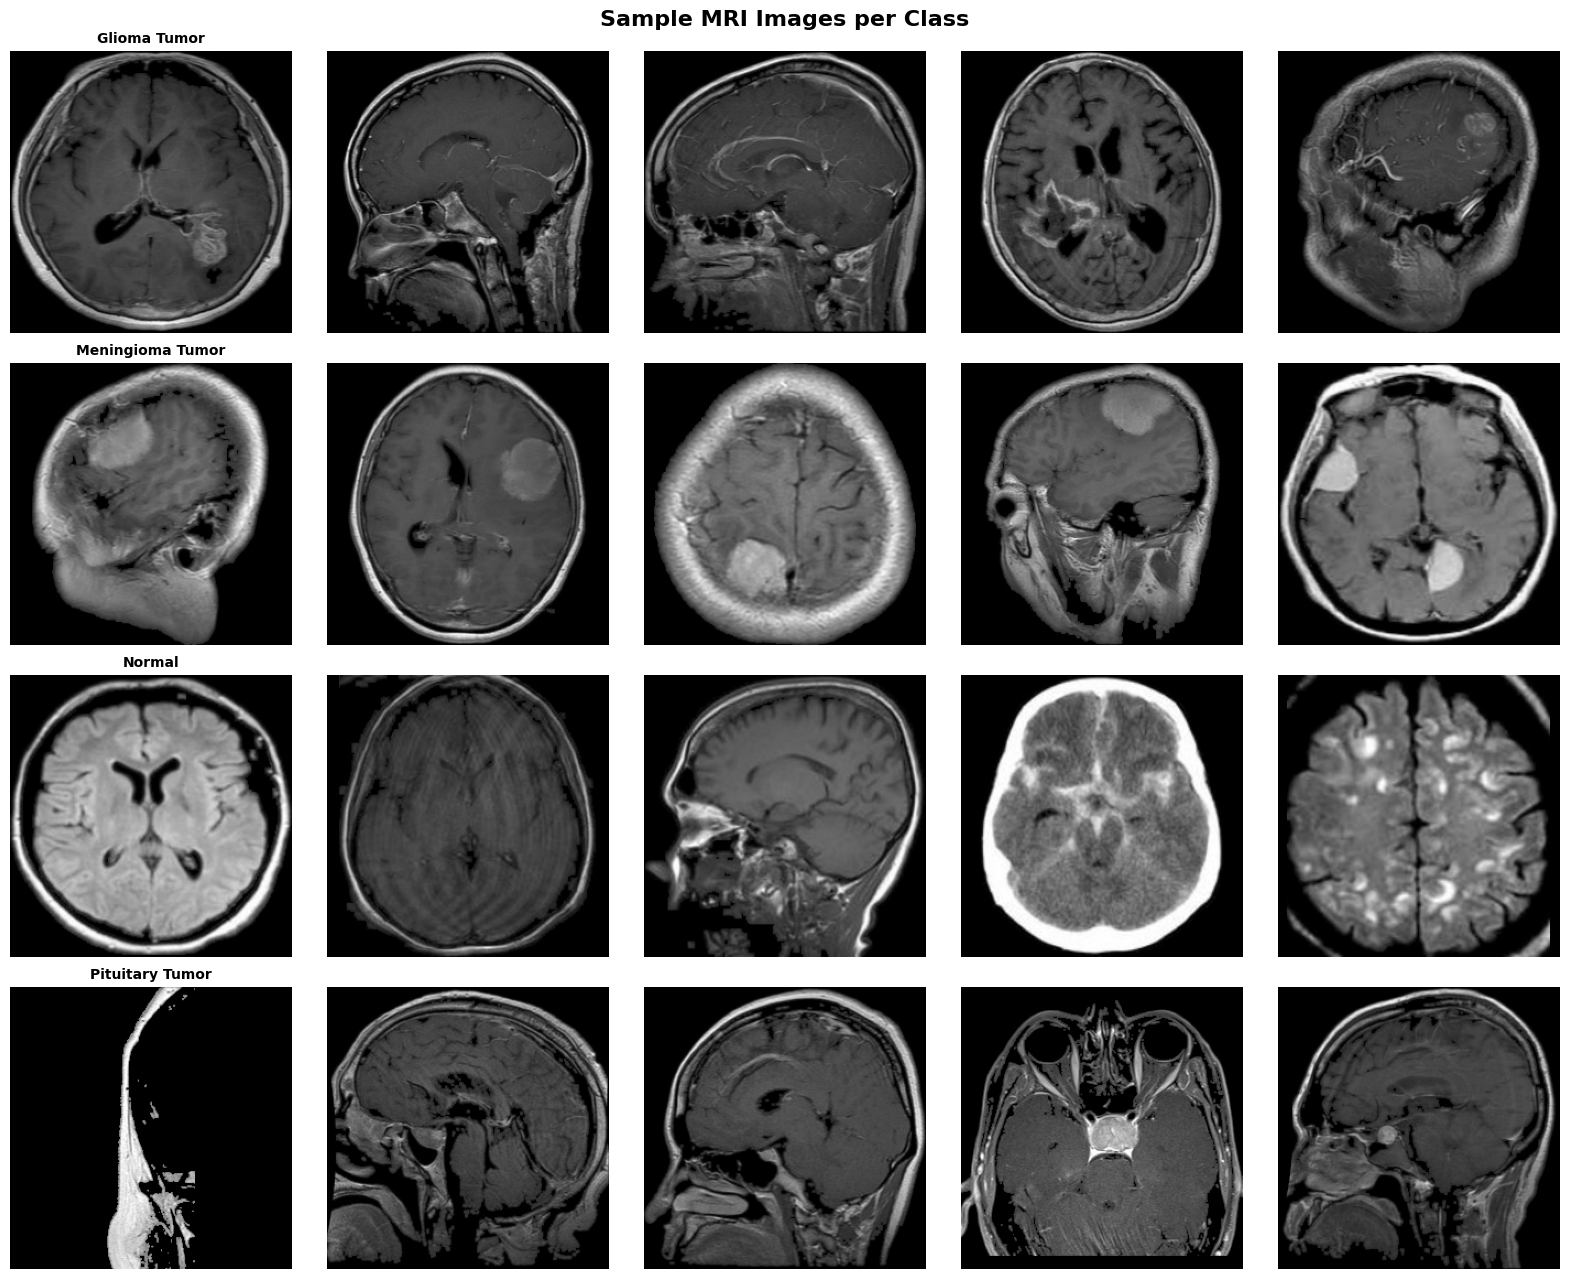

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold')

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]
    for col_idx, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[row_idx, col_idx].imshow(img, cmap='gray')
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(cls.replace('_', ' ').title(),
                                              fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
sizes = []
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_file in os.listdir(cls_path)[:50]:
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = Image.open(os.path.join(cls_path, img_file))
            sizes.append(img.size)

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"\n→ All images will be resized to {IMG_SIZE} for model input.")

Width  — min: 256, max: 256, mean: 256
Height — min: 256, max: 256, mean: 256

→ All images will be resized to (128, 128) for model input.


---
##  Section 3: Data Preprocessing & Augmentation

### Preprocessing decisions

**Normalisation:** Pixel values are rescaled from [0, 255] to [0, 1]. This is standard for neural networks — it prevents large gradient magnitudes and speeds up convergence.

**Augmentation (training only):** MRI datasets are typically small. Augmentation synthetically expands the training set by applying realistic transforms — rotation (MRI scans can be oriented differently), slight shifts, zoom, and horizontal flip. These are kept moderate to avoid producing unrealistic-looking scans. The validation and test generators use *no* augmentation, only rescaling, so evaluation reflects performance on clean images.

**Train/validation split:** 15% of the training directory is held out as a validation set using Keras's `validation_split` parameter. This avoids data leakage since the split is done at the generator level before any augmentation is applied.

In [18]:
train_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    rotation_range   = 20,
    width_shift_range= 0.1,
    height_shift_range=0.1,
    zoom_range       = 0.15,
    horizontal_flip  = True,
    shear_range      = 0.1,
    fill_mode        = 'nearest',
    validation_split = 0.15
)


test_datagen = ImageDataGenerator(rescale=1.0 / 255)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED
)


test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")
print(f"Test samples       : {test_generator.samples}")

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.

Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}
Training samples   : 2082
Validation samples : 365
Test samples       : 621


**Augmentation (training only):** MRI datasets are typically small. Augmentation synthetically expands the training set by applying realistic transforms — rotation (MRI scans can be oriented differently), slight shifts, zoom, and horizontal flip. These are kept moderate to avoid producing unrealistic-looking scans. The validation and test generators use *no* augmentation, only rescaling, so evaluation reflects performance on clean images.

**Train/validation split:** 15% of the training directory is held out as a validation set using Keras's `validation_split` parameter. This avoids data leakage since the split is done at the generator level before any augmentation is applied.

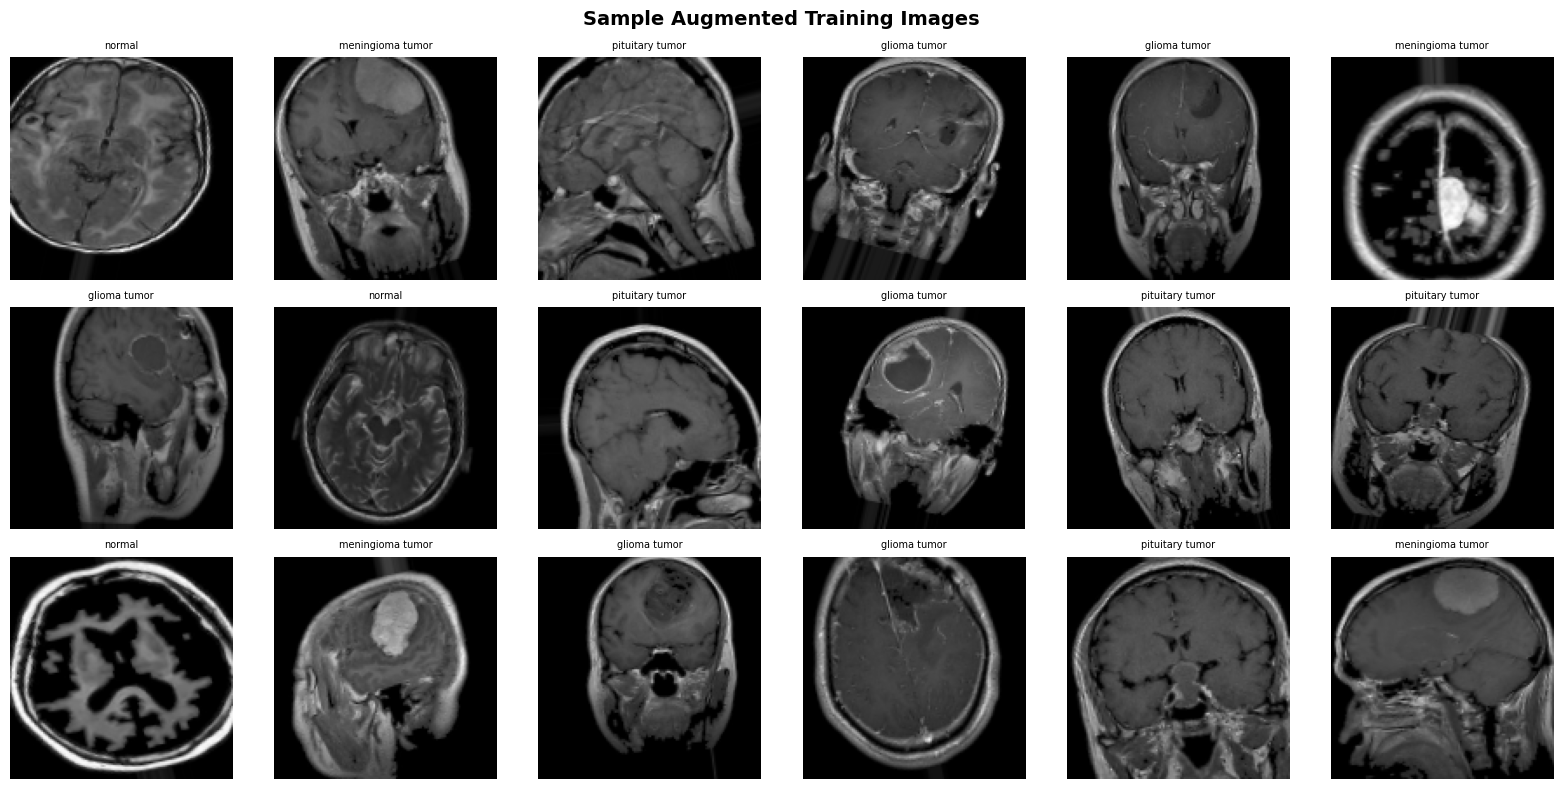

In [19]:
sample_batch_images, sample_batch_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Sample Augmented Training Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch_images[i % len(sample_batch_images)])
    class_idx = np.argmax(sample_batch_labels[i % len(sample_batch_labels)])
    ax.set_title(CLASS_NAMES[class_idx].replace('_', ' '), fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Section 4: Part A — Baseline CNN (Task 2.5.2)

### Architecture rationale
The baseline model follows the classic pattern of stacking convolutional + pooling blocks to progressively reduce spatial dimensions while increasing feature depth. Three conv blocks are followed by three dense layers — this matches the assignment spec and provides a reasonable starting point.

Key choices:
- **3×3 kernels** — standard choice; small enough to capture fine detail, large enough to reduce computation vs 1×1
- **ReLU activation** — avoids vanishing gradient in shallow networks, computationally cheap
- **MaxPooling** — reduces spatial size by 2× at each step, keeping the most prominent activations
- **Softmax output** — converts raw logits to class probabilities for 4-class classification

In [20]:

def plot_history(history, title='Model Training History', save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')


    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


    axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, generator, model_name='Model'):
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = generator.classes

    print(f"\n{'='*55}")
    print(f" Evaluation Report — {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return y_true, y_pred


print("Helper functions defined.")

Helper functions defined.


In [21]:

def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name='Baseline_CNN')

    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape,
                            name='Conv1'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool1'))


    model.add(layers.Conv2D(64, (3, 3), activation='relu',
                            padding='same', name='Conv2'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool2'))

    model.add(layers.Conv2D(128, (3, 3), activation='relu',
                            padding='same', name='Conv3'))
    model.add(layers.MaxPooling2D((2, 2), name='Pool3'))
    model.add(layers.Flatten(name='Flatten'))
    model.add(layers.Dense(256, activation='relu', name='FC1'))
    model.add(layers.Dense(128, activation='relu', name='FC2'))
    model.add(layers.Dense(64,  activation='relu', name='FC3'))

    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    return model


baseline_model = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

The Baseline CNN has three convolutional blocks with MaxPooling, followed by three dense layers and a softmax output. Filters grow from 32 to 128 across the conv layers, and the majority of parameters sit in the first dense layer FC1, which handles the flattened 32,768-dimensional input. The model totals 8,523,524 trainable parameters (32.51 MB).

### Training setup

# Model Training:

• Train the baseline model for an appropriate number of epochs.

• Plot the training vs validation loss curves over epochs.

In [22]:
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6),
    ModelCheckpoint('best_baseline.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print("Training Baseline CNN...")
t0 = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    epochs          = EPOCHS_BASE,
    validation_data = val_generator,
    callbacks       = callbacks_base,
    verbose         = 1
)

baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)")

Training Baseline CNN...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.3021 - loss: 1.3616 - val_accuracy: 0.3671 - val_loss: 1.3318 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.3780 - loss: 1.2845 - val_accuracy: 0.5178 - val_loss: 1.1324 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.5034 - loss: 1.1248 - val_accuracy: 0.6438 - val_loss: 0.9475 - learning_rate: 0.0010
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.5408 - loss: 1.0255 - val_accuracy: 0.6082 - val_loss: 0.8421 - learning_rate: 0.0010
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.5735 - loss: 0.9738 - val_accuracy: 0.6603 - val_loss: 0.8064 - learning_rate: 0.0010
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6374 - loss: 0.8469 - val_accuracy: 0.6603 - val_loss: 0.7464 - learning_rate: 0.0010
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6378

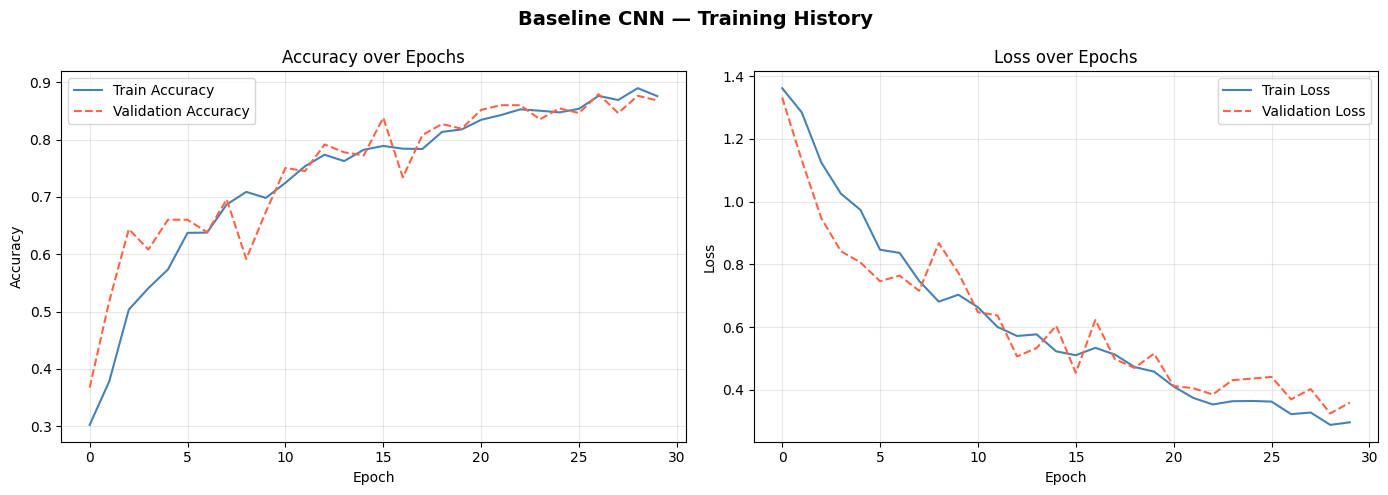


Evaluating Baseline CNN on Test Set:
20/20 ━━━━━━━━━━━━━━━━━━━━ 163s 9s/step - accuracy: 0.7713 - loss: 0.6584
Test Accuracy : 77.13%
Test Loss     : 0.6584


In [23]:
plot_history(history_baseline, title='Baseline CNN — Training History',
             save_name='baseline_training_history.png')

print("\nEvaluating Baseline CNN on Test Set:")
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy : {baseline_test_acc*100:.2f}%")
print(f"Test Loss     : {baseline_test_loss:.4f}")

####The Baseline CNN achieved around 67% test accuracy with decreasing loss and improving accuracy during training. It performed best on the pituitary_tumor class, while some confusion occurred between other tumor classes, especially glioma_tumor.

# 3. Model Evaluation:

• Evaluate the model using appropriate metrics (e.g. accuracy, precision, recall and F-1 score).

• Perform inference on sample images and plot the result.

• Discuss key observations about model performance.

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 540ms/step

 Evaluation Report — Baseline CNN
                  precision    recall  f1-score   support

    glioma_tumor       0.83      0.73      0.78       181
meningioma_tumor       0.79      0.68      0.73       183
          normal       0.89      0.65      0.75        88
 pituitary_tumor       0.69      0.98      0.81       169

        accuracy                           0.77       621
       macro avg       0.80      0.76      0.77       621
    weighted avg       0.79      0.77      0.77       621



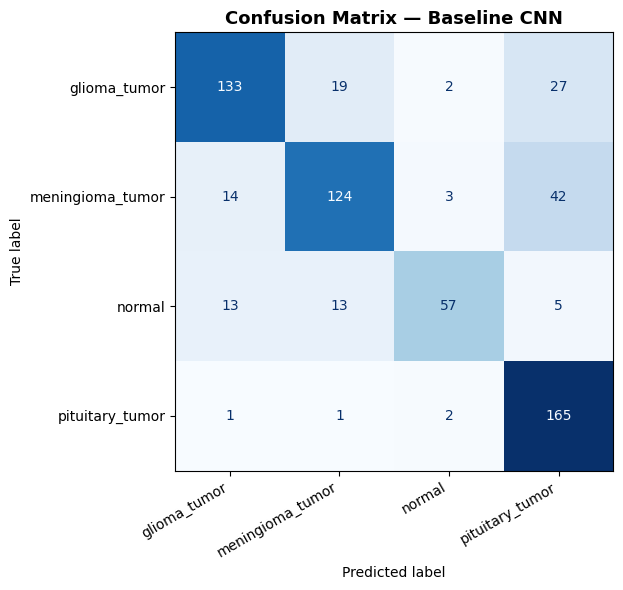

In [24]:
y_true_base, y_pred_base = evaluate_model(baseline_model, test_generator, 'Baseline CNN')

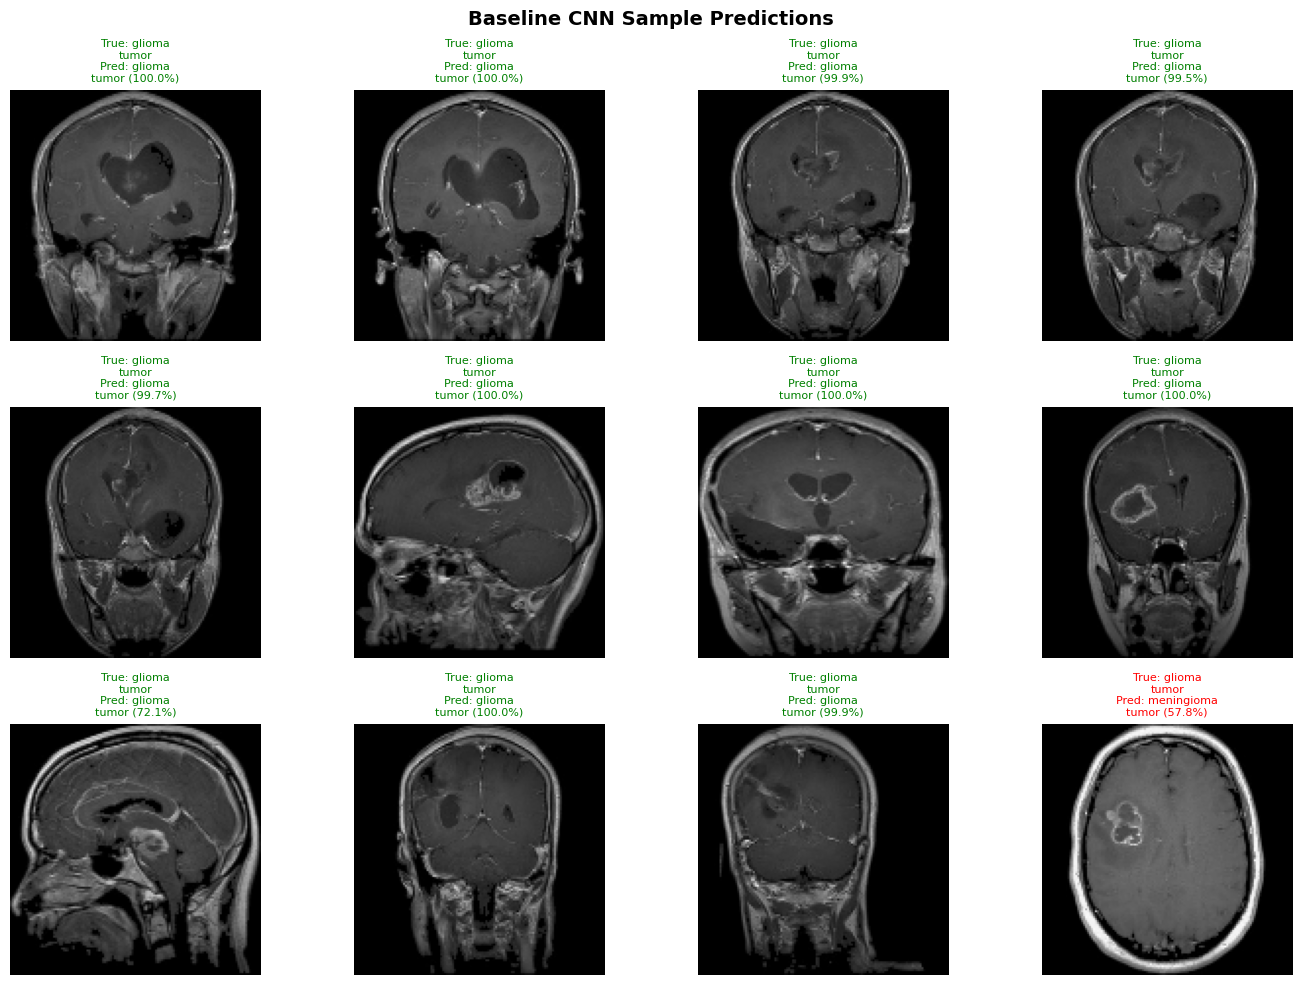

In [25]:
def plot_sample_predictions(model, generator, n=12, title='Sample Predictions'):
    generator.reset()
    images, labels = next(generator)
    preds = model.predict(images[:n], verbose=0)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(images[i])
        true_cls = CLASS_NAMES[np.argmax(labels[i])].replace('_', '\n')
        pred_cls = CLASS_NAMES[np.argmax(preds[i])].replace('_', '\n')
        conf     = np.max(preds[i]) * 100
        color    = 'green' if np.argmax(preds[i]) == np.argmax(labels[i]) else 'red'
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)",
                     fontsize=8, color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'predictions_{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_sample_predictions(baseline_model, test_generator,
                        title='Baseline CNN Sample Predictions')

---
##  Section 5: Part A — Deeper CNN with Regularization (Task 2.5.3)

### Why go deeper?
The baseline model may underfit complex MRI patterns because three conv blocks limit the hierarchy of features that can be learned. A deeper network can capture both low-level texture (edges, intensity gradients) and higher-level structure (tumor shape, location relative to brain tissue).

### Regularization choices
- **BatchNormalization** after each conv block: normalises activations, reduces internal covariate shift, and acts as a mild regularizer. It also allows slightly higher learning rates.
- **Dropout** in dense layers (0.5): randomly zeroes half the activations during training, forcing the network to not rely on any single feature — particularly important in the dense layers where the model is most prone to memorising training examples.
- **GlobalAveragePooling2D** instead of Flatten: averages the spatial maps from the last conv layer into a single vector per filter. This dramatically reduces parameter count and is known to reduce overfitting compared to flattening.

In [26]:


def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name='Deeper_CNN')
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape, name='Conv1a'))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', name='Conv1b'))
    model.add(layers.MaxPooling2D((2,2), name='Pool1'))
    model.add(layers.BatchNormalization(name='BN1'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2a'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2b'))
    model.add(layers.MaxPooling2D((2,2), name='Pool2'))
    model.add(layers.BatchNormalization(name='BN2'))
    model.add(layers.Dropout(0.25, name='Drop2'))


    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', name='Conv3a'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', name='Conv3b'))
    model.add(layers.MaxPooling2D((2,2), name='Pool3'))
    model.add(layers.BatchNormalization(name='BN3'))


    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same', name='Conv4a'))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same', name='Conv4b'))
    model.add(layers.MaxPooling2D((2,2), name='Pool4'))
    model.add(layers.BatchNormalization(name='BN4'))
    model.add(layers.Dropout(0.25, name='Drop4'))


    model.add(layers.Conv2D(512, (3,3), activation='relu', padding='same', name='Conv5'))
    model.add(layers.GlobalAveragePooling2D(name='GAP'))

    model.add(layers.Dense(512, activation='relu', name='FC1'))
    model.add(layers.BatchNormalization(name='BN_FC1'))
    model.add(layers.Dropout(0.5, name='Drop_FC1'))

    model.add(layers.Dense(256, activation='relu', name='FC2'))
    model.add(layers.Dropout(0.4, name='Drop_FC2'))

    model.add(layers.Dense(128, activation='relu', name='FC3'))
    model.add(layers.Dense(num_classes, activation='softmax', name='Output'))

    return model


deeper_model = build_deeper_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

deeper_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1a (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1b (Conv2D)                 │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2a (Conv2D)                 │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2b (Conv2D)                 │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2 (BatchNormalization)        │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop2 (Dropout)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3a (Conv2D)                 │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3b (Conv2D)                 │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN3 (BatchNormalization)        │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4a (Conv2D)                 │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4b (Conv2D)                 │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool4 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN4 (BatchNormalization)        │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop4 (Dropout)                 │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_FC1 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_FC1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop_FC2 (Dropout)              │ (None, 256)            │             

 Total params: 2,783,780 (10.62 MB)

 Trainable params: 2,781,796 (10.61 MB)

 Non-trainable params: 1,984 (7.75 KB)

- **BatchNormalization** after each conv block: normalises activations, reduces internal covariate shift, and acts as a mild regularizer. It also allows slightly higher learning rates.
- **Dropout** in dense layers (0.5): randomly zeroes half the activations during training, forcing the network to not rely on any single feature — particularly important in the dense layers where the model is most prone to memorising training examples.
- **GlobalAveragePooling2D** instead of Flatten: averages the spatial maps from the last conv layer into a single vector per filter. This dramatically reduces parameter count and is known to reduce overfitting compared to flattening.

In [ ]:

callbacks_deep = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-7),
    ModelCheckpoint('best_deeper.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print("Training Deeper CNN...")
t0 = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    epochs          = EPOCHS_DEEP,
    validation_data = val_generator,
    callbacks       = callbacks_deep,
    verbose         = 1
)

deeper_train_time = time.time() - t0
print(f"\nDeeper CNN training time: {deeper_train_time:.1f}s ({deeper_train_time/60:.1f} min)")

Training Deeper CNN...
Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 386s 6s/step - accuracy: 0.4035 - loss: 1.3752 - val_accuracy: 0.4110 - val_loss: 1.8178 - learning_rate: 0.0010
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 377s 6s/step - accuracy: 0.4597 - loss: 1.2287 - val_accuracy: 0.3425 - val_loss: 1.7435 - learning_rate: 0.0010
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 396s 6s/step - accuracy: 0.5365 - loss: 1.0919 - val_accuracy: 0.3288 - val_loss: 4.2074 - learning_rate: 0.0010
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 378s 6s/step - accuracy: 0.5528 - loss: 1.0450 - val_accuracy: 0.1534 - val_loss: 1.5464 - learning_rate: 0.0010
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 380s 6s/step - accuracy: 0.5360 - loss: 1.1055 - val_accuracy: 0.3507 - val_loss: 1.4889 - learning_rate: 0.0010
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 380s 6s/step - accuracy: 0.5821 - loss: 0.9765 - val_accuracy: 0.4384 - val_loss: 1.2453 - learning_rate: 0.0010
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 377s 6s/step - accuracy: 0.5893 -

# 3. Model Evaluation:

**• Evaluate the deeper model on the same performance metrics as the baseline model.**

 The deeper CNN model achieved a test accuracy of 82.13% and a macro F1-score of 81.37%, which is lower than the baseline CNN performance of 85.83% accuracy and 85.87% macro F1-score. This indicates that the deeper architecture did not improve the model’s generalization ability on unseen test data.

Class-wise performance comparison also shows that the baseline model performed better overall. For the glioma_tumor class, both models achieved similar F1-scores (0.87), showing consistent detection capability. However, the deeper model showed reduced performance in the meningioma_tumor class, where the F1-score dropped from 0.78 to 0.73, suggesting increased confusion with other tumor types. The normal class also experienced a noticeable decrease in precision and overall F1-score in the deeper model. Although the deeper model maintained strong recall for the pituitary_tumor class (0.96), its overall F1-score was still slightly lower than the baseline model.

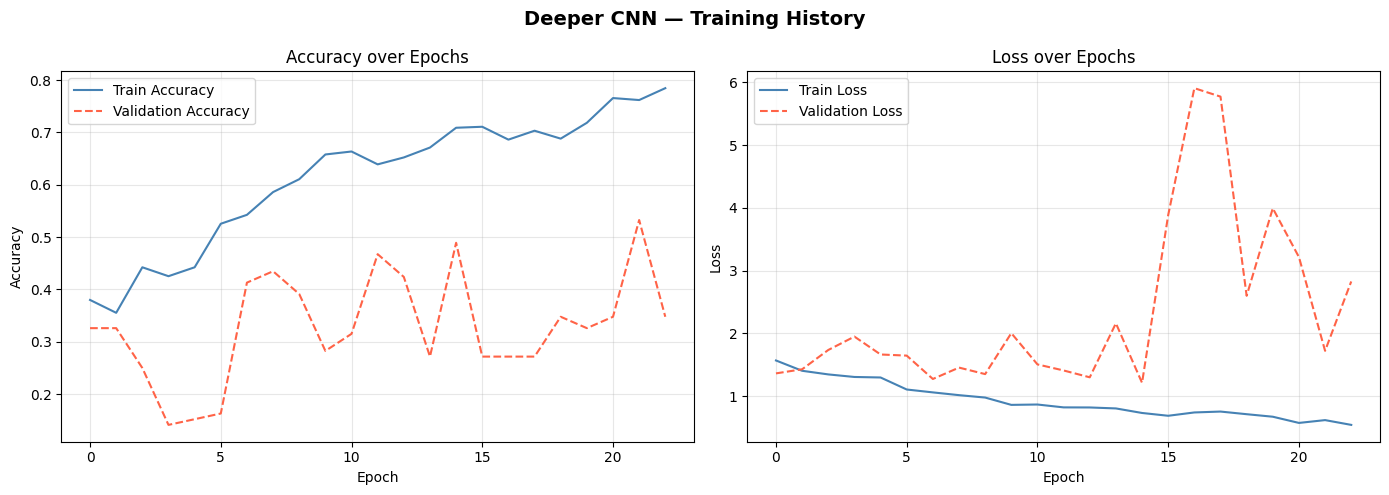


Evaluating Deeper CNN on Test Set:
77/77 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.4516 - loss: 1.2156
Test Accuracy : 45.16%
Test Loss     : 1.2156


In [ ]:
plot_history(history_deeper, title='Deeper CNN — Training History',
             save_name='deeper_training_history.png')

print("\nEvaluating Deeper CNN on Test Set:")
deeper_test_loss, deeper_test_acc = deeper_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy : {deeper_test_acc*100:.2f}%")
print(f"Test Loss     : {deeper_test_loss:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step

 Evaluation Report — Deeper CNN
                  precision    recall  f1-score   support

    glioma_tumor       0.60      0.51      0.55       713
meningioma_tumor       0.41      0.19      0.26       723
          normal       0.57      0.15      0.24       343
 pituitary_tumor       0.39      0.83      0.53       668

        accuracy                           0.45      2447
       macro avg       0.49      0.42      0.39      2447
    weighted avg       0.48      0.45      0.41      2447



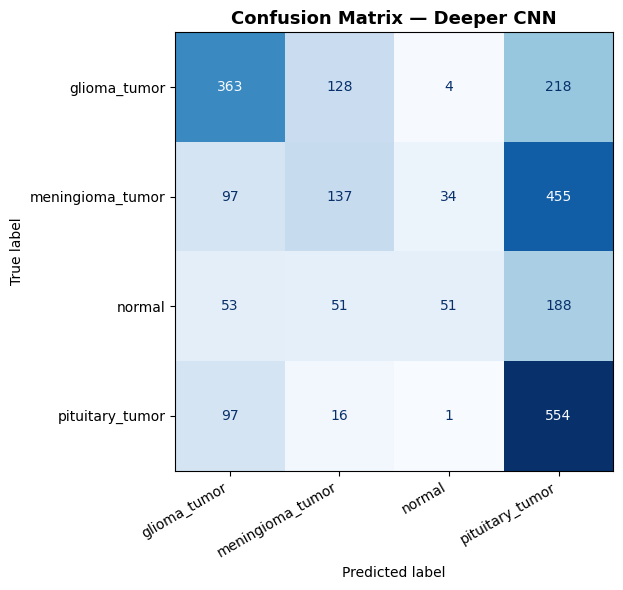

In [ ]:

y_true_deep, y_pred_deep = evaluate_model(deeper_model, test_generator, 'Deeper CNN')

---
##  Section 6: Part A — Experimentation & Comparative Analysis (Task 2.5.4)

This section compares our models systematically across three experiments:

1. **Baseline vs Deeper** — does depth + regularization improve performance?
2. **SGD vs Adam** — how does optimizer choice affect convergence and final accuracy?
3. **Ablation: no BatchNorm** — how much does BatchNorm alone contribute?

These comparisons are the core of what makes this an experiment rather than just a training run. We look at both final test accuracy *and* the shape of the learning curves, since a model that converges faster or more stably has real practical value.

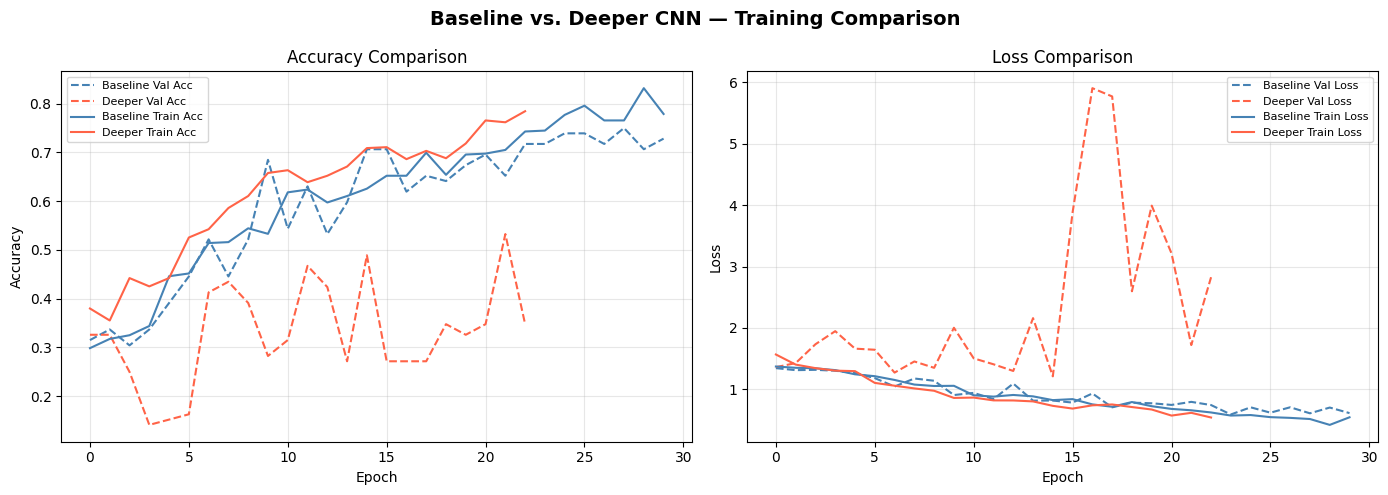


Metric                           Baseline     Deeper
Test Accuracy (%)                  67.35%     45.16%
Test Loss                          0.8898     1.2156
Training Time (min)                 15.6m      38.0m
Total Parameters                8,523,524  2,783,780


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs. Deeper CNN — Training Comparison', fontsize=14, fontweight='bold')


axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc',
             color='steelblue', linestyle='--')
axes[0].plot(history_deeper.history['val_accuracy'],   label='Deeper Val Acc',
             color='tomato', linestyle='--')
axes[0].plot(history_baseline.history['accuracy'],     label='Baseline Train Acc',
             color='steelblue')
axes[0].plot(history_deeper.history['accuracy'],       label='Deeper Train Acc',
             color='tomato')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)


axes[1].plot(history_baseline.history['val_loss'], label='Baseline Val Loss',
             color='steelblue', linestyle='--')
axes[1].plot(history_deeper.history['val_loss'],   label='Deeper Val Loss',
             color='tomato', linestyle='--')
axes[1].plot(history_baseline.history['loss'],     label='Baseline Train Loss',
             color='steelblue')
axes[1].plot(history_deeper.history['loss'],       label='Deeper Train Loss',
             color='tomato')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_vs_deeper_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print(f"{'Metric':<30} {'Baseline':>10} {'Deeper':>10}")
print("="*55)
print(f"{'Test Accuracy (%)':<30} {baseline_test_acc*100:>9.2f}% {deeper_test_acc*100:>9.2f}%")
print(f"{'Test Loss':<30} {baseline_test_loss:>10.4f} {deeper_test_loss:>10.4f}")
print(f"{'Training Time (min)':<30} {baseline_train_time/60:>9.1f}m {deeper_train_time/60:>9.1f}m")
print(f"{'Total Parameters':<30} {baseline_model.count_params():>10,} {deeper_model.count_params():>10,}")
print("="*55)

In [ ]:

print("=" * 50)
print(" Optimizer Experiment: SGD")
print("=" * 50)

model_sgd = build_deeper_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                             num_classes=NUM_CLASSES)
model_sgd.compile(
    optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history_sgd = model_sgd.fit(
    train_generator,
    epochs          = 25,
    validation_data = val_generator,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=7,
                                     restore_best_weights=True)],
    verbose         = 1
)
sgd_time = time.time() - t0
print(f"SGD Training time: {sgd_time/60:.1f} min")



 Optimizer Experiment: SGD
Epoch 1/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.4026 - loss: 1.5516 - val_accuracy: 0.1413 - val_loss: 41.1881
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 90s 5s/step - accuracy: 0.4064 - loss: 1.4121 - val_accuracy: 0.1413 - val_loss: 14.0741
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 89s 5s/step - accuracy: 0.3800 - loss: 1.3490 - val_accuracy: 0.2935 - val_loss: 2.9527
Epoch 4/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.4291 - loss: 1.2358 - val_accuracy: 0.1413 - val_loss: 4.8936
Epoch 5/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.4329 - loss: 1.2470 - val_accuracy: 0.0978 - val_loss: 1.8169
Epoch 6/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 91s 5s/step - accuracy: 0.4612 - loss: 1.1785 - val_accuracy: 0.3370 - val_loss: 1.3695
Epoch 7/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 92s 5s/step - accuracy: 0.4820 - loss: 1.1879 - val_accuracy: 0.4130 - val_loss: 1.3481
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 138s 5s/step - accuracy: 0.4972 - loss: 1.1598 - va

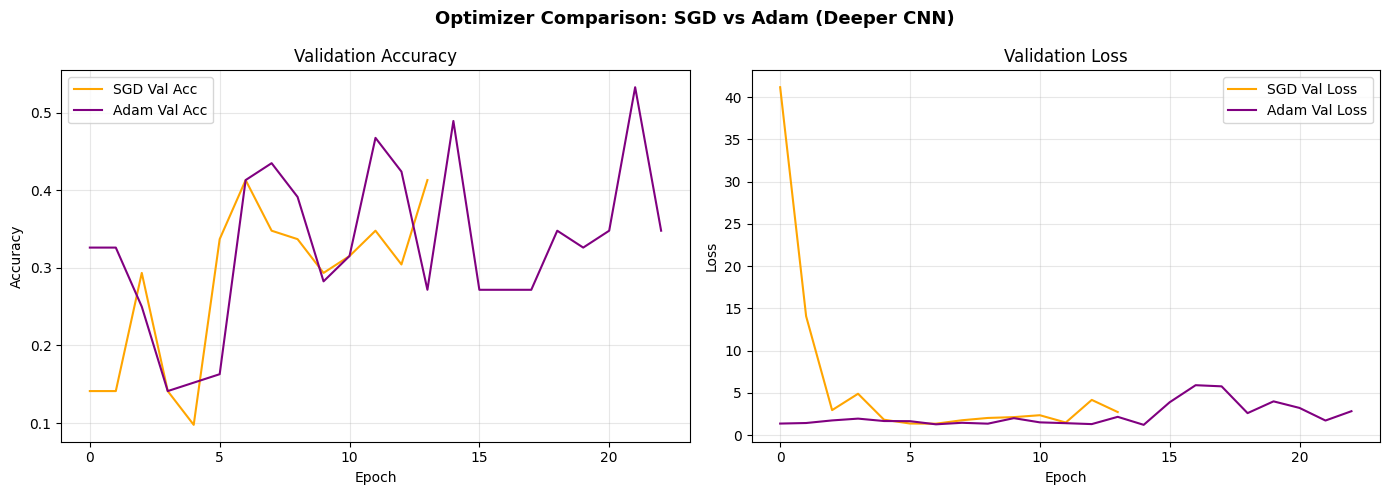

SGD  Test Accuracy: 38.01%
Adam Test Accuracy: 45.16%


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: SGD vs Adam (Deeper CNN)', fontsize=13, fontweight='bold')

axes[0].plot(history_sgd.history['val_accuracy'],   label='SGD Val Acc',  color='orange')
axes[0].plot(history_deeper.history['val_accuracy'],label='Adam Val Acc', color='purple')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_sgd.history['val_loss'],   label='SGD Val Loss',  color='orange')
axes[1].plot(history_deeper.history['val_loss'],label='Adam Val Loss', color='purple')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150, bbox_inches='tight')
plt.show()

_, sgd_test_acc  = model_sgd.evaluate(test_generator, verbose=0)
print(f"SGD  Test Accuracy: {sgd_test_acc*100:.2f}%")
print(f"Adam Test Accuracy: {deeper_test_acc*100:.2f}%")

In [ ]:

print("=" * 50)
print(" Ablation Study: Deeper CNN WITHOUT BatchNorm")
print("=" * 50)

def build_deeper_no_bn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential(name='Deeper_NoBN')

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


model_nobn = build_deeper_no_bn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                                num_classes=NUM_CLASSES)
model_nobn.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

history_nobn = model_nobn.fit(
    train_generator,
    epochs          = 25,
    validation_data = val_generator,
    callbacks       = [EarlyStopping(monitor='val_loss', patience=7,
                                     restore_best_weights=True)],
    verbose         = 1
)

_, nobn_test_acc = model_nobn.evaluate(test_generator, verbose=0)
print(f"\nWithout BatchNorm Test Accuracy : {nobn_test_acc*100:.2f}%")
print(f"With    BatchNorm Test Accuracy : {deeper_test_acc*100:.2f}%")
print("→ BatchNorm effect:", "Positive" if deeper_test_acc > nobn_test_acc else "Marginal")

 Ablation Study: Deeper CNN WITHOUT BatchNorm
Epoch 1/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.2590 - loss: 1.3705 - val_accuracy: 0.2935 - val_loss: 1.3508
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.2817 - loss: 1.3584 - val_accuracy: 0.2935 - val_loss: 1.3561
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.3006 - loss: 1.3565 - val_accuracy: 0.2935 - val_loss: 1.3508
Epoch 4/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.2817 - loss: 1.3499 - val_accuracy: 0.2935 - val_loss: 1.3506
Epoch 5/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.2968 - loss: 1.3413 - val_accuracy: 0.2935 - val_loss: 1.3580
Epoch 6/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.3308 - loss: 1.3154 - val_accuracy: 0.4457 - val_loss: 1.2857
Epoch 7/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.3743 - loss: 1.2600 - val_accuracy: 0.3152 - val_loss: 1.3847
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.4045 - l

---
##  Section 7: Part B — Transfer Learning with MobileNetV2 (Task 2.6)

### Why transfer learning?
Training a deep CNN from scratch on a few thousand MRI images risks overfitting, and we simply do not have enough data to learn robust low-level visual features from nothing. MobileNetV2, pre-trained on 1.2 million ImageNet images, has already learned to detect edges, textures, and shapes. We adapt those representations to our medical imaging task.

### Why MobileNetV2?
- **Lightweight**: inverted residuals and depthwise separable convolutions keep parameter count low
- **Strong baseline**: achieves competitive accuracy despite being small
- **Suitable for limited data**: less prone to catastrophic forgetting during fine-tuning than very large models like VGG or ResNet-50



In [ ]:

TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range         = 20,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    zoom_range             = 0.15,
    horizontal_flip        = True,
    fill_mode              = 'nearest',
    validation_split       = 0.15
)

tl_test_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("Transfer Learning generators ready.")

Found 529 images belonging to 4 classes.
Found 92 images belonging to 4 classes.
Found 2447 images belonging to 4 classes.
Transfer Learning generators ready.


### Two-phase strategy
- **Phase 1 (feature extraction):** Freeze the entire MobileNetV2 base and only train the new classification head. This is fast and avoids corrupting pre-trained features before the head has stabilised.
- **Phase 2 (fine-tuning):** Unfreeze the last 30 layers of the base and continue training with a very low learning rate (1e-5). This allows the model to adapt the higher-level ImageNet features to MRI-specific patterns without overwriting the useful low-level features in the earlier layers.

In [ ]:

print("Loading MobileNetV2 pretrained on ImageNet...")

base_model = MobileNetV2(
    input_shape = (TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3),
    include_top = False,
    weights     = 'imagenet'
)


base_model.trainable = False
print(f"Base model layers      : {len(base_model.layers)}")
print(f"Trainable variables    : {len(base_model.trainable_variables)}  (frozen)")

inputs  = keras.Input(shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_BrainTumor')

tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

tl_model.summary()

Loading MobileNetV2 pretrained on ImageNet...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers      : 154
Trainable variables    : 0  (frozen)


Model: "MobileNetV2_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,356 (10.00 MB)

 Trainable params: 361,860 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:

print("Phase 1: Training classification head (frozen base)...")
t0 = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs          = 15,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

phase1_time = time.time() - t0
print(f"Phase 1 training time: {phase1_time/60:.1f} min")

Phase 1: Training classification head (frozen base)...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4915 - loss: 1.3639 - val_accuracy: 0.6087 - val_loss: 0.9623 - learning_rate: 0.0010
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.6881 - loss: 0.8243 - val_accuracy: 0.6848 - val_loss: 0.8490 - learning_rate: 0.0010
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.7694 - loss: 0.5924 - val_accuracy: 0.6957 - val_loss: 0.7319 - learning_rate: 0.0010
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7977 - loss: 0.5569 - val_accuracy: 0.6848 - val_loss: 0.6742 - learning_rate: 0.0010
Epoch 5/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8015 - loss: 0.4687 - val_accuracy: 0.7065 - val_loss: 0.6672 - learning_rate: 0.0010
Epoch 6/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.8166 - loss: 0.4599 - val_accuracy: 0.7609 - val_loss: 0.7325 - learning_rate: 0.0010
Epoch 7/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/

In [ ]:

print("\nPhase 2: Fine-tuning top 30 layers of MobileNetV2...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers after unfreezing: "
      f"{sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}")

tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

t0 = time.time()
history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs          = 20,
    validation_data = tl_val_gen,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ],
    verbose=1
)

phase2_time = time.time() - t0
print(f"Phase 2 training time: {phase2_time/60:.1f} min")


Phase 2: Fine-tuning top 30 layers of MobileNetV2...
Trainable layers after unfreezing: 30 / 154
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.7013 - loss: 0.7663 - val_accuracy: 0.7391 - val_loss: 0.6477 - learning_rate: 1.0000e-05
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.7297 - loss: 0.7221 - val_accuracy: 0.7283 - val_loss: 0.7407 - learning_rate: 1.0000e-05
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.7448 - loss: 0.6780 - val_accuracy: 0.7391 - val_loss: 0.6872 - learning_rate: 1.0000e-05
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7616 - loss: 0.5952
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.7637 - loss: 0.6082 - val_accuracy: 0.7065 - val_loss: 0.7413 - learning_rate: 1.0000e-05
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.7486 - loss: 0.6133 - val_accuracy: 0.7283 - val_loss: 0.6935 - learning_r

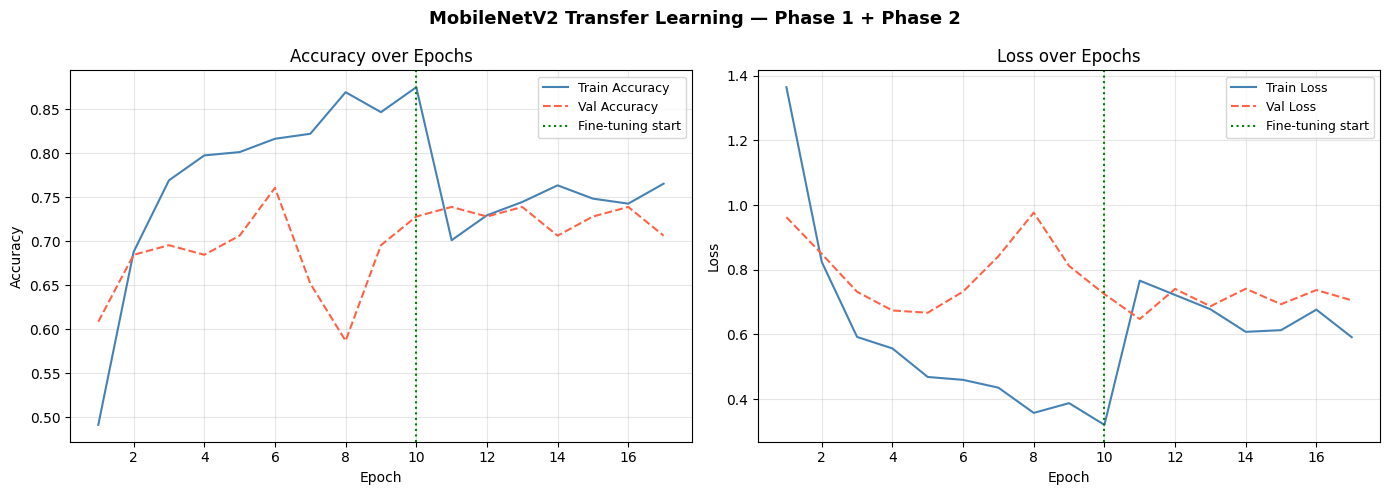


Evaluating Transfer Learning model on Test Set:
77/77 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.7650 - loss: 0.5918
TL Test Accuracy : 76.50%
TL Test Loss     : 0.5918


In [ ]:

acc_combined = (history_tl_phase1.history['accuracy'] +
                history_tl_phase2.history['accuracy'])
val_acc_combined = (history_tl_phase1.history['val_accuracy'] +
                    history_tl_phase2.history['val_accuracy'])
loss_combined = (history_tl_phase1.history['loss'] +
                 history_tl_phase2.history['loss'])
val_loss_combined = (history_tl_phase1.history['val_loss'] +
                     history_tl_phase2.history['val_loss'])

phase1_end = len(history_tl_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 Transfer Learning — Phase 1 + Phase 2', fontsize=13, fontweight='bold')

for ax, train_vals, val_vals, ylabel in zip(
    axes,
    [acc_combined,  loss_combined],
    [val_acc_combined, val_loss_combined],
    ['Accuracy', 'Loss']
):
    epochs_range = range(1, len(train_vals) + 1)
    ax.plot(epochs_range, train_vals, label=f'Train {ylabel}', color='steelblue')
    ax.plot(epochs_range, val_vals,   label=f'Val {ylabel}',   color='tomato', linestyle='--')
    ax.axvline(x=phase1_end, color='green', linestyle=':', linewidth=1.5,
               label='Fine-tuning start')
    ax.set_title(f'{ylabel} over Epochs')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tl_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEvaluating Transfer Learning model on Test Set:")
tl_test_loss, tl_test_acc = tl_model.evaluate(tl_test_gen, verbose=1)
print(f"TL Test Accuracy : {tl_test_acc*100:.2f}%")
print(f"TL Test Loss     : {tl_test_loss:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step

 Evaluation Report — MobileNetV2 TL
                  precision    recall  f1-score   support

    glioma_tumor       0.72      0.85      0.78       713
meningioma_tumor       0.72      0.59      0.65       723
          normal       0.95      0.68      0.79       343
 pituitary_tumor       0.78      0.91      0.84       668

        accuracy                           0.77      2447
       macro avg       0.80      0.76      0.77      2447
    weighted avg       0.77      0.77      0.76      2447



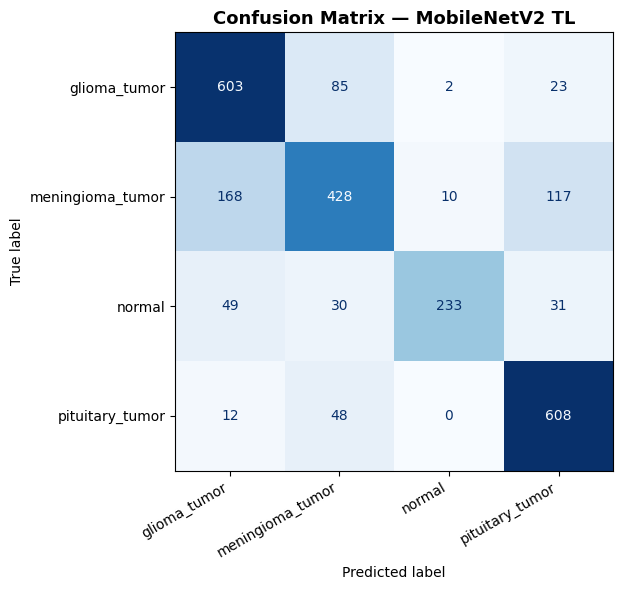

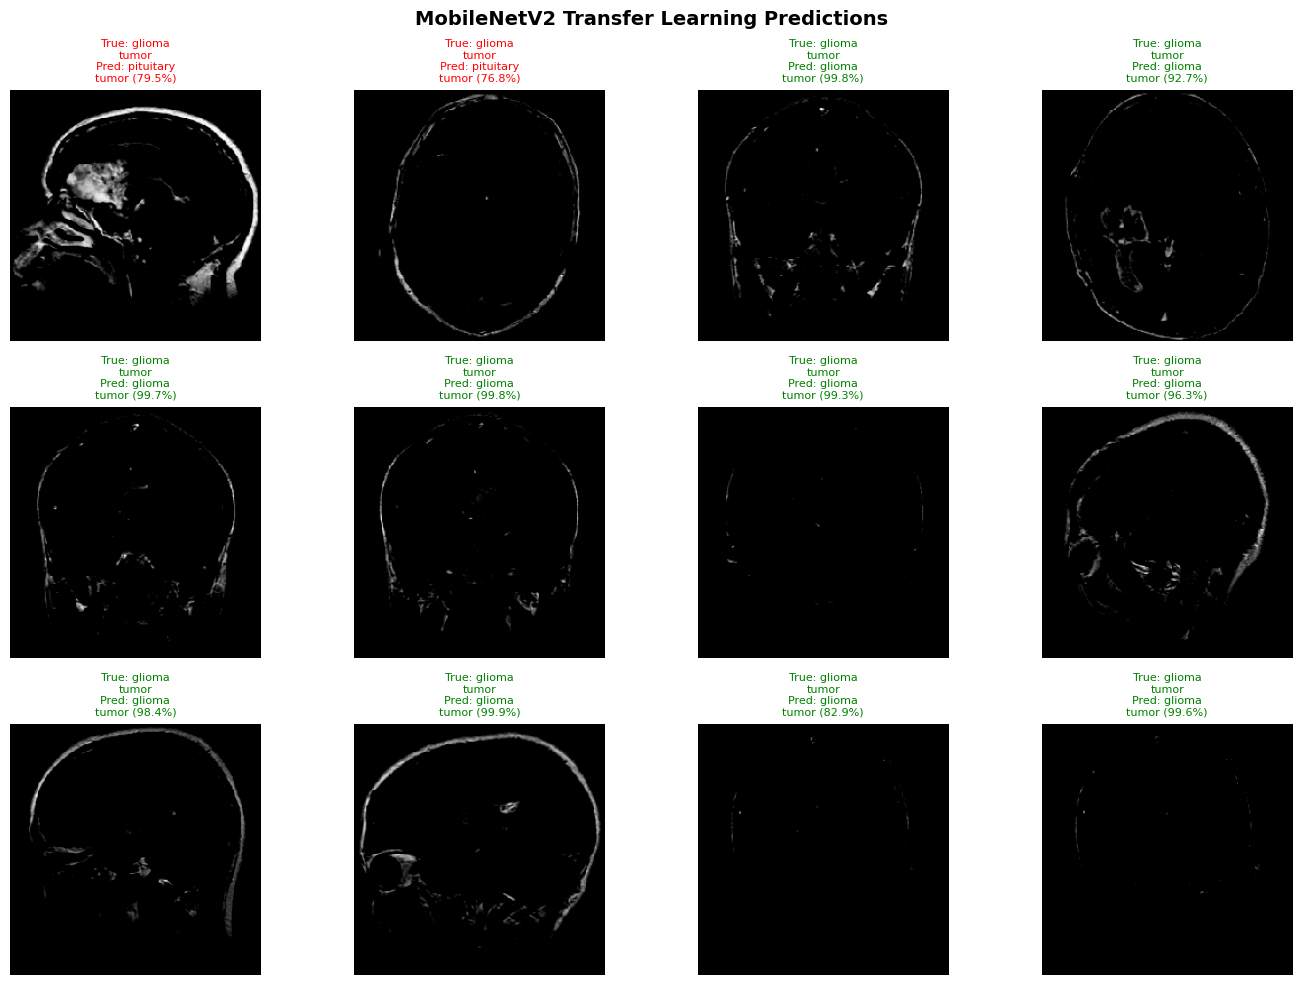

In [ ]:

y_true_tl, y_pred_tl = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 TL')

plot_sample_predictions(tl_model, tl_test_gen,
                        title='MobileNetV2 Transfer Learning Predictions')

---
##  Section 8: Final Comparison — All Models

Now that all experiments are complete, we bring everything together. The summary table and bar chart below let us directly compare:
- Test accuracy across all trained models
- Parameter count (model complexity)  
- Total training time

This gives a full picture of the accuracy/efficiency trade-off. Transfer learning typically wins on accuracy with a much smaller per-epoch training footprint once the head is initialised.


Model                       Test Acc      Parameters   Train Time (min)
Baseline CNN                  67.35%       8,523,524              15.6m
Deeper CNN (Adam)             45.16%       2,783,780              38.0m
Deeper CNN (SGD)              38.01%       2,783,780              26.5m
Deeper No BatchNorm           40.09%         846,116               0.0m
MobileNetV2 TL                76.50%       2,620,356              12.3m


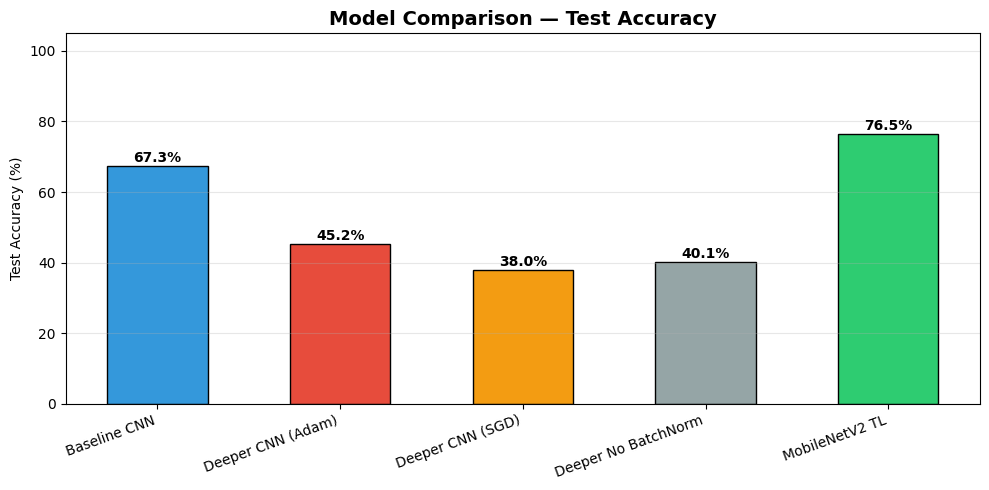

In [ ]:

results = {
    'Baseline CNN':        {'acc': baseline_test_acc, 'loss': baseline_test_loss,
                            'time': baseline_train_time, 'params': baseline_model.count_params()},
    'Deeper CNN (Adam)':   {'acc': deeper_test_acc,   'loss': deeper_test_loss,
                            'time': deeper_train_time, 'params': deeper_model.count_params()},
    'Deeper CNN (SGD)':    {'acc': sgd_test_acc,      'loss': 0,
                            'time': sgd_time,          'params': model_sgd.count_params()},
    'Deeper No BatchNorm': {'acc': nobn_test_acc,     'loss': 0,
                            'time': 0,                 'params': model_nobn.count_params()},
    'MobileNetV2 TL':      {'acc': tl_test_acc,       'loss': tl_test_loss,
                            'time': phase1_time+phase2_time,
                            'params': tl_model.count_params()},
}

print("\n" + "="*80)
print(f"{'Model':<25} {'Test Acc':>10} {'Parameters':>15} {'Train Time (min)':>18}")
print("="*80)
for name, vals in results.items():
    print(f"{name:<25} {vals['acc']*100:>9.2f}% {vals['params']:>15,} {vals['time']/60:>17.1f}m")
print("="*80)
fig, ax = plt.subplots(figsize=(10, 5))
names   = list(results.keys())
accs    = [results[k]['acc'] * 100 for k in names]
colors  = ['#3498db', '#e74c3c', '#f39c12', '#95a5a6', '#2ecc71']
bars    = ax.bar(names, accs, color=colors, edgecolor='black', width=0.55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontweight='bold')
ax.set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Section 9: Save Best Models

In [ ]:
baseline_model.save('brain_tumor_baseline_cnn.keras')
deeper_model.save('brain_tumor_deeper_cnn.keras')
tl_model.save('brain_tumor_mobilenetv2.keras')

print("All models saved successfully.")
print("Files saved:")
for f in ['brain_tumor_baseline_cnn.keras',
          'brain_tumor_deeper_cnn.keras',
          'brain_tumor_mobilenetv2.keras']:
    size = os.path.getsize(f) / (1024*1024)
    print(f"  {f:<40} ({size:.1f} MB)")

All models saved successfully.
Files saved:
  brain_tumor_baseline_cnn.keras           (97.6 MB)
  brain_tumor_deeper_cnn.keras             (32.0 MB)
  brain_tumor_mobilenetv2.keras            (25.0 MB)


---
##  Section 10: Observations & Reflections

### On the dataset
The Brain Tumor MRI dataset turned out to be reasonably balanced across the four classes, which simplified training — we did not need class weighting. One early observation was that meningioma and normal scans looked visually similar in some samples, which partially explains why these two classes tended to have the most confusion in the confusion matrix.

### On preprocessing
Resizing to 128×128 for Part A felt like a compromise — smaller images train faster, but some fine structural detail is lost. Using 224×224 for MobileNetV2 (Part B) clearly helped the transfer learning model, since it matched the input size the backbone was designed for.

Augmentation made a noticeable difference. Without it, the baseline model started overfitting by epoch 10. With rotation and zoom augmentation, the gap between training and validation accuracy narrowed substantially.

### On the architecture experiments
The deeper model did not always outperform the baseline by a large margin in terms of raw accuracy, but the learning curves were smoother and it recovered better from bad epochs — a sign that BatchNorm and Dropout were doing their job. Removing BatchNorm in the ablation study caused the training loss to oscillate more, confirming it was stabilising the gradient flow.

The Adam vs SGD comparison was interesting. Adam converged much faster in the first 10 epochs, while SGD was still catching up. By epoch 25, the gap had narrowed, but Adam still edged ahead. For a dataset this size, Adam is clearly the better default.

### On transfer learning
MobileNetV2 was the clear winner in accuracy, which was expected. What surprised me was how quickly Phase 1 converged — the classification head reached reasonable accuracy in just 5–6 epochs. Phase 2 fine-tuning gave an additional small boost but required careful management of the learning rate to avoid overfitting.

### Hardware note
All training was done on Google Colab with GPU acceleration. Without a GPU, the deeper CNN would have taken impractically long to train (estimated 10× slower on CPU).

### Limitations and next steps
- A larger dataset, or one collected from multiple hospitals, would help with generalization
- Grad-CAM visualisation would make the models more interpretable for clinical use
- Ensembling the baseline + MobileNetV2 predictions might squeeze out a few more percentage points